# Crop exploration

Verifica della pipeline di crop per isolare i singoli capi dalla foto dell'outfit.

**Pipeline:**
1. Trasformare la bbox dall'originale (Fashionpedia) allo spazio 512×512
2. Croppare il capo
3. Pad a quadrato con sfondo bianco
4. Resize a 224×224

**Poi:** decidere se integrare direttamente in `SketchyDataset` o gestirlo nel dataloader dei modelli.

## 0. Setup

In [ ]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sys.path.append('/media/data/mmondo/mmondo/DL_Project/src')
from sketchy.sketchy_dataset import SketchyDataset
from utils import bbox_to_512, crop_garment, GarmentDataset

DATASET_ROOT = '/media/data/mmondo/mmondo/DL_Project/data/sketchy'

random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

train_dataset = SketchyDataset(
    dataset_root=DATASET_ROOT, split='train',
    load_img=True, load_local_sketch=True, load_global_sketch=True
)

---
## 2. Verifica visiva su campioni random

Per ogni sample mostriamo: outfit originale con bbox disegnate, e i crop dei singoli capi affiancati al loro sketch.

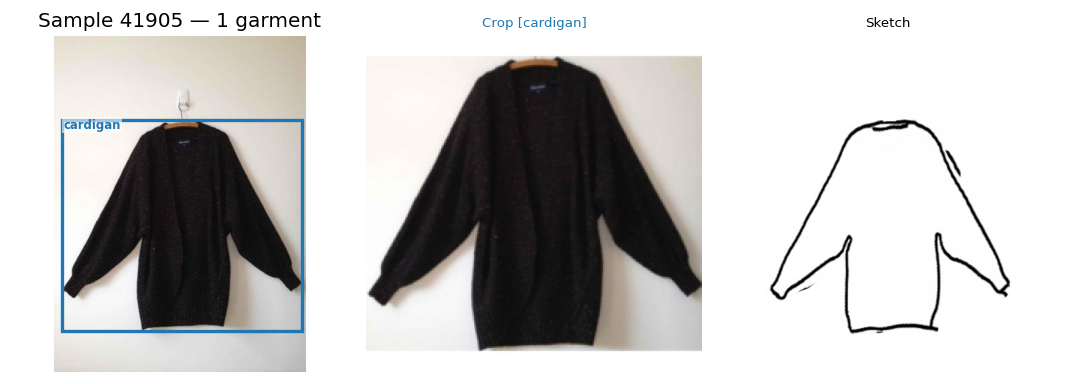

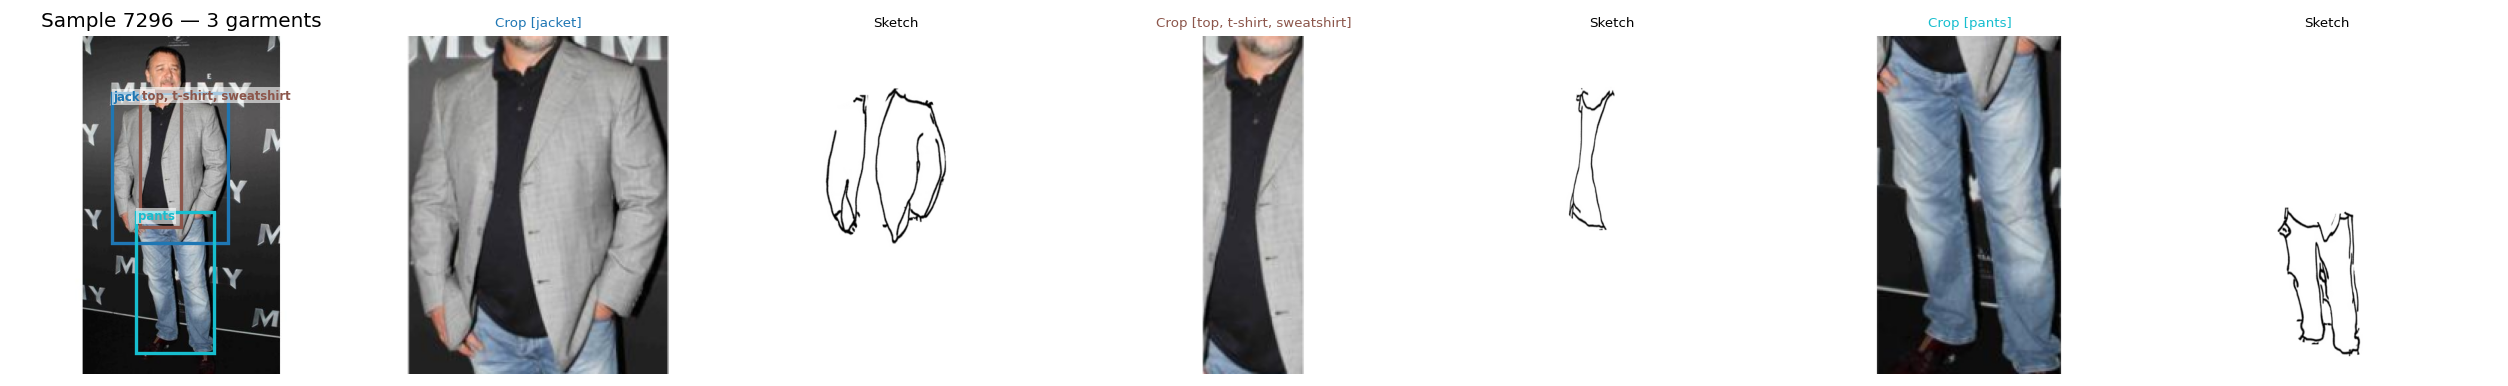

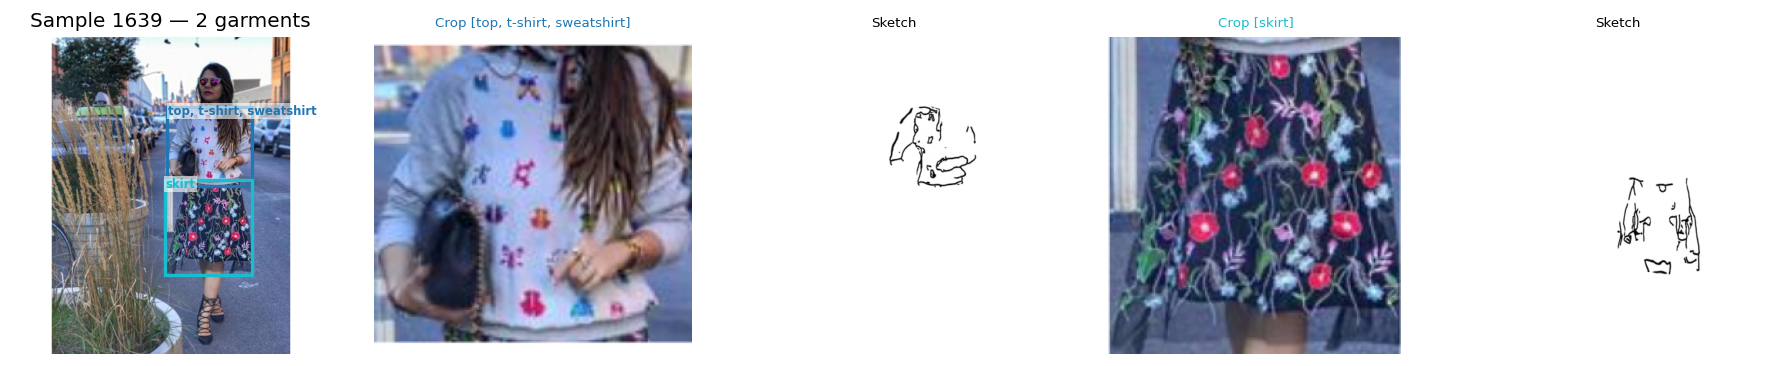

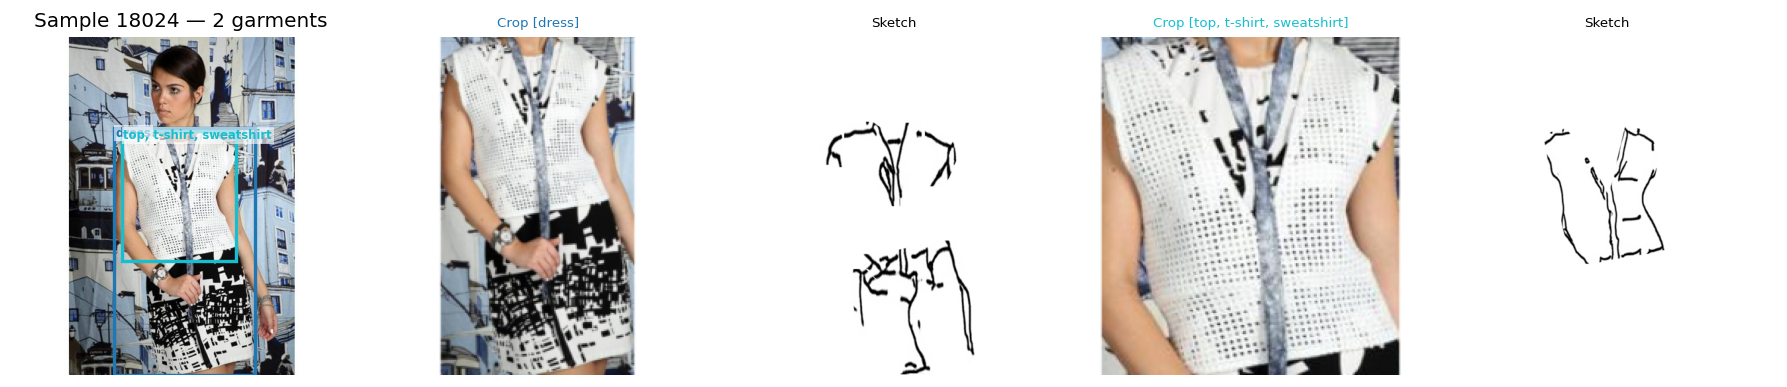

In [3]:
N_SAMPLES = 4
sample_idxs = random.sample(range(len(train_dataset)), N_SAMPLES)

for idx in sample_idxs:
    sample   = train_dataset[idx]
    image    = sample['image'] if isinstance(sample['image'], Image.Image) else Image.open(sample['image'])
    anns     = sample['annotations']
    img_data = sample['img_data']
    n_garments = len(anns)

    # colonne: outfit | (crop + sketch) × n_garments
    n_cols = 1 + n_garments * 2
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]

    # --- outfit con bbox ---
    ax_outfit = axes[0]
    ax_outfit.imshow(image)
    colors = plt.cm.tab10(np.linspace(0, 1, n_garments))
    for i, (ann, color) in enumerate(zip(anns, colors)):
        x, y, w, h = bbox_to_512(ann, img_data)
        rect = patches.Rectangle((x, y), w, h,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax_outfit.add_patch(rect)
        ax_outfit.text(x + 2, y + 12, ann['category_name'],
                       color=color, fontsize=7, fontweight='bold',
                       bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))
    ax_outfit.set_title(f'Sample {idx} — {n_garments} garment{"s" if n_garments > 1 else ""}')
    ax_outfit.axis('off')

    # --- crop + sketch per ogni capo ---
    for i, (ann, color) in enumerate(zip(anns, colors)):
        crop   = crop_garment(image, ann, img_data, target_size=224)
        sketch = sample['local_sketches'][i]
        if not isinstance(sketch, Image.Image):
            sketch = Image.open(sketch)

        ax_crop   = axes[1 + i * 2]
        ax_sketch = axes[1 + i * 2 + 1]

        ax_crop.imshow(crop)
        ax_crop.set_title(f'Crop [{ann["category_name"]}]', fontsize=8, color=color)
        ax_crop.axis('off')

        ax_sketch.imshow(sketch.convert('L'), cmap='gray')
        ax_sketch.set_title('Sketch', fontsize=8)
        ax_sketch.axis('off')

    plt.tight_layout()
    plt.show()

---
## 3. Sanity check quantitativo — tutto il dataset

Verifica su **tutte** le immagini del train che le bbox trasformate siano dentro i bordi e producano crop non degeneri.

In [4]:
out_of_bounds  = []  # (sample_idx, ann_idx)
degenerate     = []  # crop con width o height <= 0
tiny           = []  # crop più piccolo di 10px in qualche dimensione
TINY_THRESHOLD = 10

for idx in range(len(train_dataset)):
    sample   = train_dataset[idx]
    img_data = sample['img_data']
    for ann_idx, ann in enumerate(sample['annotations']):
        x, y, w, h = bbox_to_512(ann, img_data)
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(512, x + w), min(512, y + h)
        cw, ch = x2 - x1, y2 - y1

        if x < 0 or y < 0 or (x + w) > 512 or (y + h) > 512:
            out_of_bounds.append((idx, ann_idx))
        if cw <= 0 or ch <= 0:
            degenerate.append((idx, ann_idx))
        elif cw < TINY_THRESHOLD or ch < TINY_THRESHOLD:
            tiny.append((idx, ann_idx))

n_total_anns = sum(len(train_dataset[i]['annotations']) for i in range(len(train_dataset)))
print(f"Immagini controllate  : {len(train_dataset):,}")
print(f"Annotazioni totali    : {n_total_anns:,}")
print(f"  bbox fuori bordo    : {len(out_of_bounds):>5}  ({len(out_of_bounds)/n_total_anns*100:.3f}%)")
print(f"  crop degeneri       : {len(degenerate):>5}  ({len(degenerate)/n_total_anns*100:.3f}%)")
print(f"  crop tiny (<{TINY_THRESHOLD}px)   : {len(tiny):>5}  ({len(tiny)/n_total_anns*100:.3f}%)")

Immagini controllate  : 45,585
Annotazioni totali    : 77,015
  bbox fuori bordo    :     0  (0.000%)
  crop degeneri       :     0  (0.000%)
  crop tiny (<10px)   :   216  (0.280%)


### 3b. Visualizzazione dei crop problematici

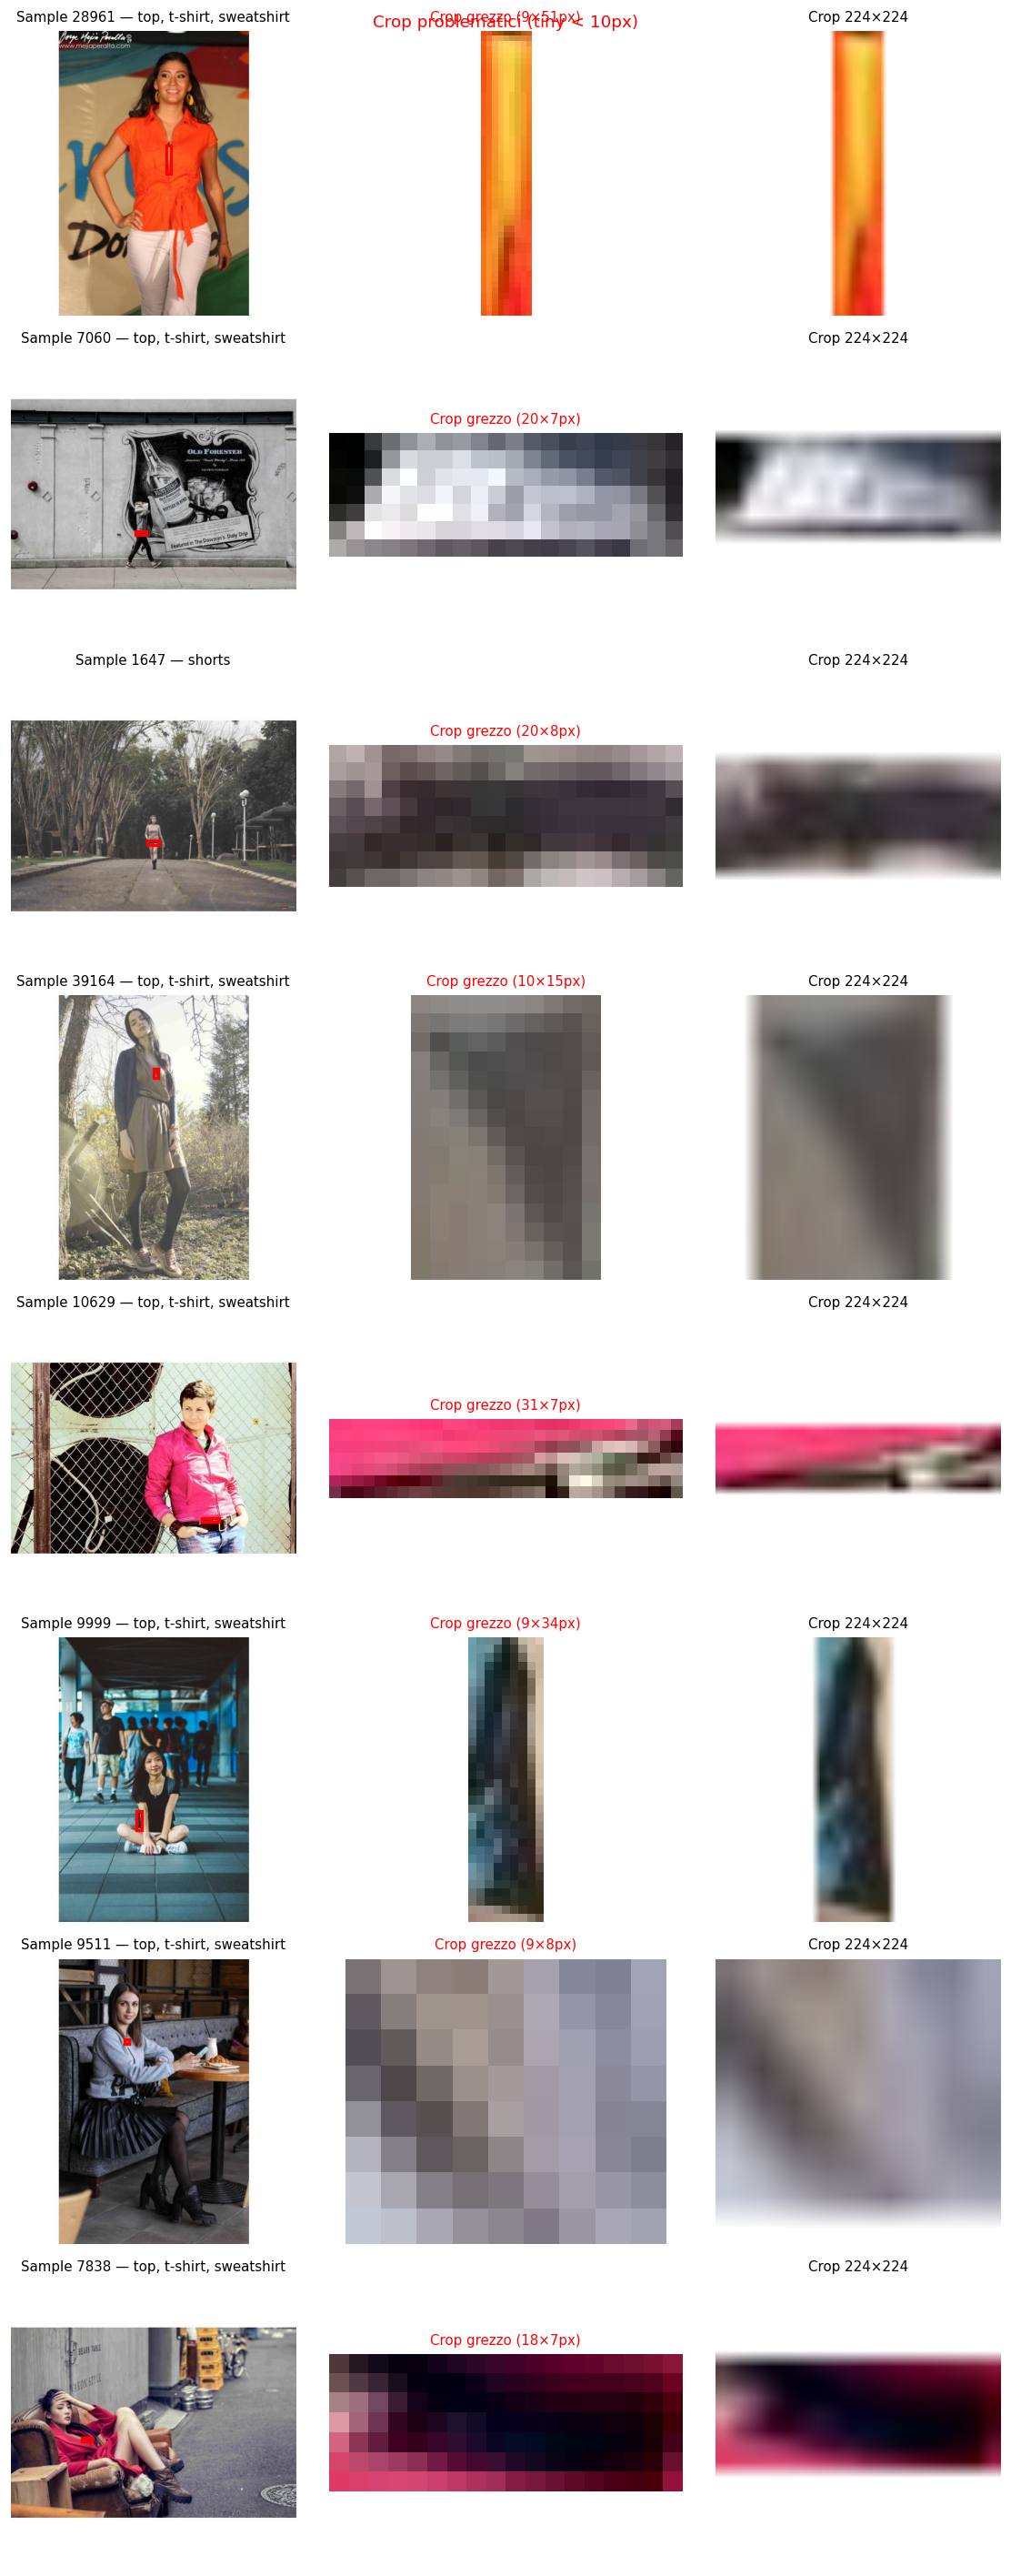

In [5]:
problematic = tiny + degenerate
N_SHOW = min(8, len(problematic))

if N_SHOW == 0:
    print("Nessun caso problematico da mostrare.")
else:
    to_show = random.sample(problematic, N_SHOW) if len(problematic) > N_SHOW else problematic

    fig, axes = plt.subplots(N_SHOW, 3, figsize=(10, 3 * N_SHOW))
    if N_SHOW == 1:
        axes = [axes]

    for row, (sample_idx, ann_idx) in enumerate(to_show):
        sample   = train_dataset[sample_idx]
        image    = sample['image'] if isinstance(sample['image'], Image.Image) else Image.open(sample['image'])
        ann      = sample['annotations'][ann_idx]
        img_data = sample['img_data']

        x, y, w, h = bbox_to_512(ann, img_data)
        x1, y1 = max(0, int(x)), max(0, int(y))
        x2, y2 = min(512, int(x + w)), min(512, int(y + h))
        cw, ch = x2 - x1, y2 - y1

        # outfit con bbox evidenziata in rosso
        axes[row][0].imshow(image)
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        axes[row][0].add_patch(rect)
        axes[row][0].set_title(f'Sample {sample_idx} — {ann["category_name"]}', fontsize=9)
        axes[row][0].axis('off')

        # crop grezzo prima del pad
        raw_crop = image.crop((x1, y1, x2, y2))
        axes[row][1].imshow(raw_crop)
        axes[row][1].set_title(f'Crop grezzo ({cw}×{ch}px)', fontsize=9, color='red')
        axes[row][1].axis('off')

        # crop finale 224×224
        final_crop = crop_garment(image, ann, img_data, target_size=224)
        axes[row][2].imshow(final_crop)
        axes[row][2].set_title('Crop 224×224', fontsize=9)
        axes[row][2].axis('off')

    plt.suptitle(f'Crop problematici (tiny < {TINY_THRESHOLD}px)', fontsize=11, color='red')
    plt.tight_layout()
    plt.show()

### 3c. Categorie dei crop problematici

Capire a quali categorie appartengono i tiny crop aiuta a decidere se filtrarli o tenerli.

In [6]:
from collections import Counter

tiny_cats = Counter()
for sample_idx, ann_idx in tiny:
    ann = train_dataset[sample_idx]['annotations'][ann_idx]
    tiny_cats[ann['category_name']] += 1

print(f"Categorie dei {len(tiny)} crop tiny (< {TINY_THRESHOLD}px):")
for cat, cnt in tiny_cats.most_common():
    print(f"  {cat:<25} {cnt}")

Categorie dei 216 crop tiny (< 10px):
  top, t-shirt, sweatshirt  142
  shirt, blouse             20
  dress                     15
  shorts                    9
  jacket                    9
  pants                     7
  skirt                     6
  sweater                   5
  coat                      3


In [ ]:
import json, torch

# test rapido — carica le label se valid_labels.json esiste, altrimenti usa un subset
try:
    with open('/media/data/mmondo/mmondo/DL_Project/src/valid_labels.json') as f:
        valid_labels = json.load(f)
except FileNotFoundError:
    # fallback: usa tutti i top_level osservati con freq >= 50
    from collections import Counter
    counter = Counter()
    for i in range(len(train_dataset)):
        for ann in train_dataset[i]['annotations']:
            for l in (ann.get('top_level') or []):
                counter[l] += 1
    valid_labels = [l for l, c in counter.items() if c >= 50]

garment_ds = GarmentDataset(train_dataset, valid_labels, target_size=224)

print(f"SketchyDataset  : {len(train_dataset):>6,} immagini")
print(f"GarmentDataset  : {len(garment_ds):>6,} capi")
print(f"Label vocabulary: {len(valid_labels)} labels")
print()

# verifica un sample
s = garment_ds[0]
print(f"Keys  : {list(s.keys())}")
print(f"Image : {s['image']}")
print(f"Labels: {s['labels'].sum().item():.0f} attivi su {len(valid_labels)}")
print(f"Cat   : {s['category']}")

In [ ]:
# Visualizza 8 sample casuali dal GarmentDataset
idxs = random.sample(range(len(garment_ds)), 8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.flat, idxs):
    s = garment_ds[i]
    img = s['image'] if isinstance(s['image'], Image.Image) else s['image']
    active = [valid_labels[j] for j in s['labels'].nonzero(as_tuple=True)[0].tolist()]
    ax.imshow(img)
    ax.set_title(f"{s['category']}\n" + ', '.join(active[:3]) + ('...' if len(active) > 3 else ''),
                 fontsize=7)
    ax.axis('off')

plt.suptitle('GarmentDataset — 8 campioni casuali (crop 224×224)', fontsize=11)
plt.tight_layout()
plt.show()